<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/PROCESOS_DERIVDAS_DEL_MB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<span style="color:blue;">**PROCESOS DERIVDAS DEL MB**</span>

* <span style="color:blue;">**Puente Browviano**</span>

Es el proceso

$$
X_{t}=B_t -tB_1 \quad , \quad 0 ≤t≤1
$$

Obviamente
$$X_0=0 \quad , \quad X_1=0 \quad E(X_t)= cov(X_t,X_s)$$

* <span style="color:blue;">**Movimiento Browviano deriva**</span>
$$
X_t= \mu t + σB_t \quad , \quad t \geq0
$$
 para $$\mu ϵ R \quad y \quad σ>0$$
 $$E(X_t)= cov(X_t,X_s)$$

 * <span style="color:blue;">**Movimiento Browviano Generativa**</span>

 $$
X_{t}=e ^{\mu t + σB_t} \quad , \quad  t \geq0
$$

**MOVIMIENTO BROWNIAC**

*Seudocódigo*

1. $dt=\frac{T}{L}$
2. $W_0=0$
3. Para $i=0$ a $L-1$
4. Calcule un $\xi_i\sim N (0,1)$
5. $W_{i+1}=W_i+ \sqrt {dt}\xi _1$
6. Terminar

Procedamos a programar el seudocódigo

In [8]:
import numpy as np
import matplotlib.pyplot as plt

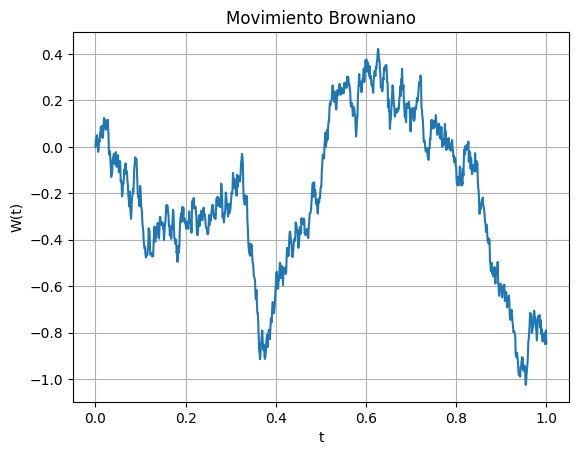

In [9]:

# Parámetros
T = 1.0      # horizonte temporal
L = 1000     # número de pasos

# Paso temporal
dt = T / L

# Vector de tiempos
t = np.linspace(0, T, L + 1)

# Movimiento Browniano
W = np.zeros(L + 1)

for i in range(L):
    xi = np.random.normal(0, 1)
    W[i + 1] = W[i] + np.sqrt(dt) * xi

# Graficar
plt.plot(t, W)
plt.title("Movimiento Browniano")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.grid()
plt.show()

Teóricamente:
$$E[Wt​]=0$$
$$Cov(Wt​,Ws​)=min(t,s).$$

In [10]:
import numpy as np

# Parámetros
T = 1
L = 1000
M = 10000

dt = T/L
t = np.linspace(0, T, L+1)

# Simular M trayectorias
W = np.zeros((M, L+1))

for k in range(M):
    incrementos = np.sqrt(dt)*np.random.randn(L)
    W[k,1:] = np.cumsum(incrementos)

# Elegimos dos tiempos
t0 = 0.4
s0 = 0.7

i = int(t0*L)
j = int(s0*L)

# Esperanza empírica
E_emp = np.mean(W[:,i])

# Covarianza empírica
Cov_emp = np.cov(W[:,i], W[:,j])[0,1]

print("E[W_t] empírica =", E_emp)
print("E[W_t] teórica =", 0)

print("Cov empírica =", Cov_emp)
print("Cov teórica =", min(t0,s0))

E[W_t] empírica = -0.004643805253196266
E[W_t] teórica = 0
Cov empírica = 0.39777242278760144
Cov teórica = 0.4


Puente Browniano

Usando
 $$Xt​=Wt​−tWT​$$
(donde T=1 coincide con tu definición).

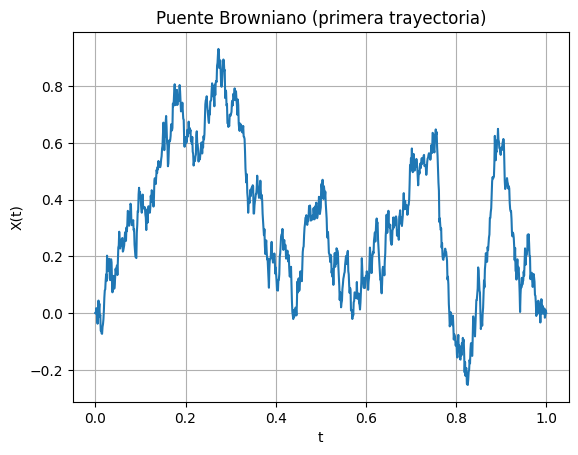

X(0) = 0.0
X(T) = 0.0


In [12]:
# Puente Browniano
# W now contains multiple trajectories, so B will also contain multiple trajectories.
# To plot a single Brownian Bridge, select one trajectory, for example, the first one.
B_single_trajectory = W[0, :] - t * W[0, -1]

plt.plot(t, B_single_trajectory)
plt.title("Puente Browniano (primera trayectoria)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

print("X(0) =", B_single_trajectory[0])
print("X(T) =", B_single_trajectory[-1])


In [16]:
# Puentes Brownianos
Bridge = W - t*W[:,-1][:,None]

E_emp = np.mean(Bridge[:,i])

Cov_emp = np.cov(
    Bridge[:,i],
    Bridge[:,j]
)[0,1]

Cov_teo = min(t0,s0) - t0*s0

print("E empírica =", E_emp)
print("E teórica =", 0)

print("Cov empírica =", Cov_emp)
print("Cov teórica =", Cov_teo)

E empírica = -0.0016006973735794069
E teórica = 0
Cov empírica = 0.12253512364189328
Cov teórica = 0.12000000000000005


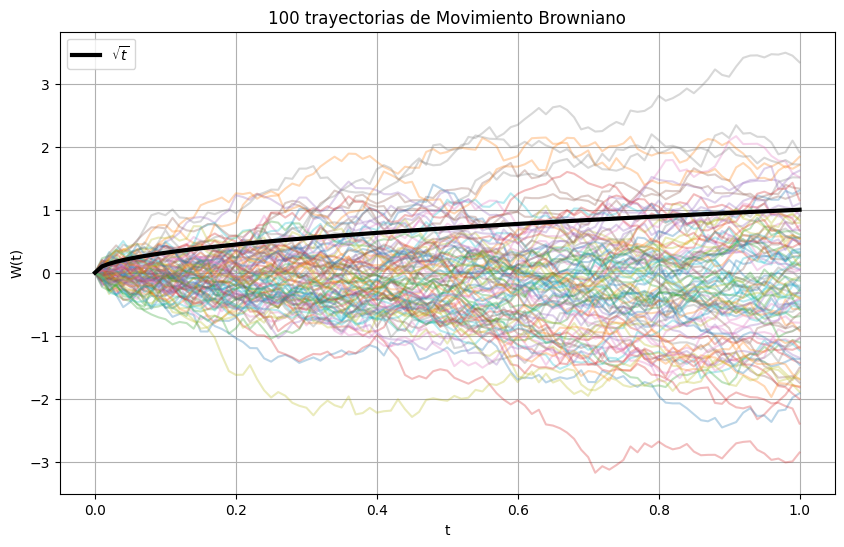

In [17]:

T = 1
L = 100
N = 100

dt = T / L
t = np.linspace(0, T, L + 1)

# Incrementos gaussianos
dW = np.sqrt(dt) * np.random.randn(N, L)

# Trayectorias
W = np.cumsum(dW, axis=1)

# Agregar W0=0
W = np.column_stack((np.zeros(N), W))

plt.figure(figsize=(10,6))

for k in range(N):
    plt.plot(t, W[k], alpha=0.3)

plt.plot(t, np.sqrt(t), 'k', lw=3, label=r'$\sqrt{t}$')

plt.title("100 trayectorias de Movimiento Browniano")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.legend()
plt.grid(True)
plt.show()

Movimiento Browniano con deriva
$$Xt​=μt+σWt​$$

In [ ]:
mu = 0.5
sigma = 1.2

X_drift = mu * t + sigma * W

plt.plot(t, X_drift)
plt.title("Movimiento Browniano con deriva")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

Fórmulas teóricas

Esperanza:

$$E[Xt​]=μt.$$

Covarianza: $$Cov(Xt​,Xs​)=σ2min(t,s)$$

In [ ]:
mu = 0.5
sigma = 1.2

Drift = mu*t + sigma*W

E_emp = np.mean(Drift[:,i])

Cov_emp = np.cov(
    Drift[:,i],
    Drift[:,j]
)[0,1]

print("E empírica =", E_emp)
print("E teórica =", mu*t0)

print("Cov empírica =", Cov_emp)
print("Cov teórica =", sigma**2 * min(t0,s0))

Movimiento Browniano geométrico
$$Xt​=eμt+σWt​$$



Esperanza teórica
 $$Wt​∼N(0,t)$$


$$E[Xt​]=eμt+21​σ2t.$$
Covarianza teórica
Usando momentos de la normal:
$$E[Xt​Xs​]=exp(μ(t+s)+2σ2​(t+s)+σ2min(t,s))$$
y $$Cov(Xt​,Xs​)=E[Xt​Xs​]−E[Xt​]E[Xs​].$$
Equivalentemente, $$Cov(Xt​,Xs​)=eμ(t+s)+2σ2​(t+s)(eσ2min(t,s)−1)$$


In [13]:
Geo = np.exp(mu*t + sigma*W)

E_emp = np.mean(Geo[:,i])

Cov_emp = np.cov(
    Geo[:,i],
    Geo[:,j]
)[0,1]

E_teo = np.exp(
    mu*t0 + 0.5*sigma**2*t0
)

Cov_teo = np.exp(
    mu*(t0+s0)
    + 0.5*sigma**2*(t0+s0)
) * (
    np.exp(
        sigma**2 * min(t0,s0)
    ) - 1
)

print("E empírica =", E_emp)
print("E teórica =", E_teo)

print("Cov empírica =", Cov_emp)
print("Cov teórica =", Cov_teo)

E empírica = 1.616145110182957
E teórica = 1.6290548499725743
Cov empírica = 2.807344828773718
Cov teórica = 2.9806409496203567


Y para la covarianza:

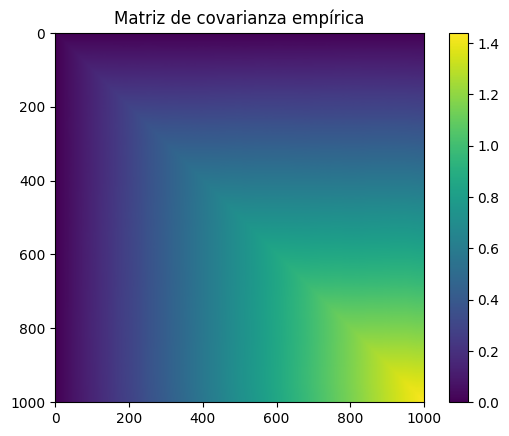

In [15]:
Drift = mu*t + sigma*W
Cov_emp = np.cov(Drift.T)

plt.imshow(Cov_emp)
plt.colorbar()
plt.title("Matriz de covarianza empírica")
plt.show()


In [ ]:
X_geo = np.exp(mu * t + sigma * W)

plt.plot(t, X_geo)
plt.title("Movimiento Browniano Geométrico")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

1. Movimiento Browniano estándar
$$Wt​,t≥0$$
Recordemos que:$$Wt​∼N(0,t)$$
